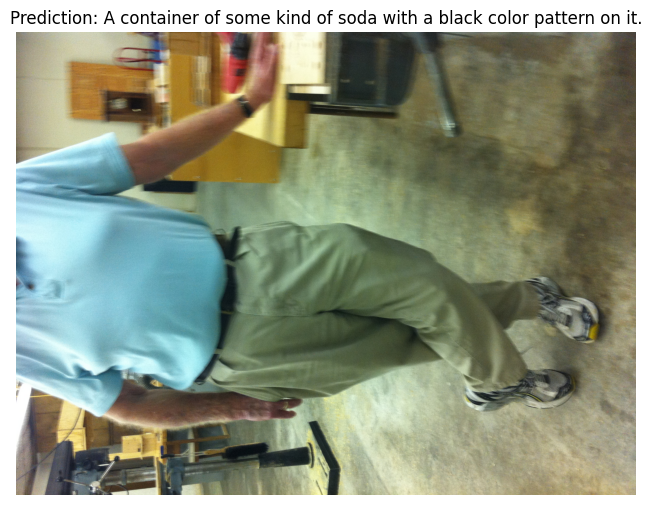

Max length: 100
File: VizWiz_train_00014355.jpg
Validation split settings: val_ratio=0.1, split_seed=42

Prediction:
A container of some kind of soda with a black color pattern on it.

Ground-truth captions:
1. An adult whose head is not in frame is standing in a workroom and wearing khaki pants, a blue polo shirt, and tennis shoes.
2. a male person standing in front of it with cross leg position
3. person standing with legs crossed leaning against a table.
4. A middle-aged man wearing a blue polo and khakis is standing cross-legged leaning on a nearby desk and his head is out of frame
5. a man standing and resting on a table with his leg crossed


In [147]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

from captioning import load_checkpoint
from dataset import VizWizCaptionDataset, load_annotations, split_train_val

idx_to_experiment = {
    0 : "runs/runs_frozen_encoder/baseline_resnet18_gru_char",
    1 : "runs/runs_frozen_encoder/encoder_resnet34_gru_char",
    2 : "runs/runs_frozen_encoder/decoder_resnet18_lstm_char",
    3 : "runs/runs_frozen_encoder/token_resnet18_gru_word",
    4 : "runs/runs_frozen_encoder/attention_resnet18_gru_char",
    5 : "runs/runs_frozen_encoder/combined_resnet34_lstm_word_attention",
    6 : "runs/runs_frozen_encoder_scheduled/baseline_resnet18_gru_char_scheduled_sampling",
    7 : "runs/runs_frozen_encoder_scheduled/encoder_resnet34_gru_char_scheduled_sampling",
    8 : "runs/runs_frozen_encoder_scheduled/decoder_resnet18_lstm_char_scheduled_sampling",
    9 : "runs/runs_frozen_encoder_scheduled/token_resnet18_gru_word_scheduled_sampling",
    10 : "runs/runs_frozen_encoder_scheduled/attention_resnet18_gru_char_scheduled_sampling",
    11 : "runs/runs_frozen_encoder_scheduled/combined_resnet34_lstm_word_attention_scheduled_sampling",
    12: "runs/final_baseline_trainable_encoder_scheduled"
}

idx = 12

run_dir = Path(idx_to_experiment[idx])
data_dir = Path("data")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, tokenizer, config = load_checkpoint(run_dir / "best.pt", device=device)

# Fallback to the training defaults if the checkpoint config does not store them
val_ratio = config.get("val_ratio", 0.1)
split_seed = config.get("split_seed", 42)

all_samples = load_annotations(data_dir / "annotations" / "train.json")
_, val_samples = split_train_val(
    all_samples,
    val_ratio=val_ratio,
    seed=split_seed,
)

sample = random.choice(val_samples)

transform = VizWizCaptionDataset(
    data_dir=data_dir,
    samples=[],
    tokenizer=tokenizer,
    max_len=config["max_len"],
    training=False,
).transform

image_path = data_dir / "train" / sample.file_name
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    generated = model.generate(
        images=image_tensor,
        sos_id=tokenizer.sos_id,
        eos_id=tokenizer.eos_id,
        max_len= config["max_len"],
    )

# print("Generated token IDs:", generated[0].tolist())
pred_caption = tokenizer.decode(generated[0].tolist())

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {pred_caption.capitalize()}")
plt.show()

print(f"Max length: {config['max_len']}")
print("File:", sample.file_name)
print(f"Validation split settings: val_ratio={val_ratio}, split_seed={split_seed}")

print("\nPrediction:")
print(pred_caption.capitalize())

print("\nGround-truth captions:")
for i, ref in enumerate(sample.captions, 1):
    print(f"{i}. {ref}")


In [ ]:
# xulo per visualitzar results :) posar path del tsv i yata

import pandas as pd
from pathlib import Path

tsv_paths = [
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week3/runs/runs_frozen_encoder/experiment_summary.tsv",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week3/runs/runs_frozen_encoder_scheduled/experiment_summary.tsv",
    # add more here
]

def load_experiment_tsv(path):
    path = Path(path)
    df = pd.read_csv(path, sep="\t")
    df["source_file"] = str(path)
    df["source_name"] = path.parent.name

    numeric_cols = [
        "scheduled_sampling_max_ratio",
        "lr",
        "lr_decay_factor",
        "lr_decay_patience",
        "early_stopping_patience",
        "best_epoch",
        "bleu1",
        "bleu2",
        "rougeL",
        "meteor",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    bool_cols = ["attention", "pretrained_encoder", "scheduled_sampling"]
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})

    df["score_sum"] = df[["bleu1", "bleu2", "rougeL", "meteor"]].sum(axis=1)
    df["score_main"] = df[["bleu2", "rougeL", "meteor"]].sum(axis=1)
    return df

dfs = [load_experiment_tsv(path) for path in tsv_paths]
all_results = pd.concat(dfs, ignore_index=True)

print("Loaded files:")
display(all_results[["source_name", "source_file"]].drop_duplicates().reset_index(drop=True))

print("\nBest run per file by bleu2 + rougeL + meteor:")
best_per_file = (
    all_results.sort_values("score_main", ascending=False)
    .groupby("source_name", as_index=False)
    .first()
)
display(
    best_per_file[
        [
            "source_name", "run", "encoder", "decoder", "token_level", "attention",
            "pretrained_encoder", "scheduled_sampling", "best_epoch",
            "bleu1", "bleu2", "rougeL", "meteor", "score_main"
        ]
    ].sort_values("score_main", ascending=False)
)

print("\nTop 10 runs overall:")
display(
    all_results[
        [
            "source_name", "run", "encoder", "decoder", "token_level", "attention",
            "pretrained_encoder", "scheduled_sampling", "best_epoch",
            "bleu1", "bleu2", "rougeL", "meteor", "score_main"
        ]
    ]
    .sort_values("score_main", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\nAverage metrics by source file:")
display(
    all_results.groupby("source_name")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)

print("\nAverage metrics by token level:")
display(
    all_results.groupby("token_level")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)

print("\nAverage metrics by encoder:")
display(
    all_results.groupby("encoder")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)

print("\nAverage metrics by decoder:")
display(
    all_results.groupby("decoder")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)

print("\nAverage metrics by attention:")
display(
    all_results.groupby("attention")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)

print("\nAverage metrics by scheduled_sampling:")
display(
    all_results.groupby("scheduled_sampling")[["bleu1", "bleu2", "rougeL", "meteor", "score_main"]]
    .mean()
    .sort_values("score_main", ascending=False)
)


Loaded files:


,source_name,source_file
0,runs_frozen_encoder,/DATA/home/jgarcia/SpectralSegmentation/C5-Pro...
1,runs_frozen_encoder_scheduled,/DATA/home/jgarcia/SpectralSegmentation/C5-Pro...



Best run per file by bleu2 + rougeL + meteor:


,source_name,run,encoder,decoder,token_level,attention,pretrained_encoder,scheduled_sampling,best_epoch,bleu1,bleu2,rougeL,meteor,score_main
1,runs_frozen_encoder_scheduled,baseline_resnet18_gru_char_scheduled_sampling,resnet18,gru,char,False,False,True,7,0.5272,0.3555,0.4219,0.3716,1.149
0,runs_frozen_encoder,encoder_resnet34_gru_char,resnet34,gru,char,False,False,None,10,0.5181,0.3474,0.4149,0.3657,1.128



Top 10 runs overall:


...

,bleu1,bleu2,rougeL,meteor,score_main
decoder,,,,,
gru,0.480175,0.321525,0.388900,0.342025,1.052450
lstm,0.483075,0.329575,0.381525,0.330875,1.041975



Average metrics by attention:


,bleu1,bleu2,rougeL,meteor,score_main
attention,,,,,
True,0.500475,0.337200,0.385800,0.335100,1.058100
False,0.471475,0.317713,0.386763,0.339913,1.044388



Average metrics by scheduled_sampling:


,bleu1,bleu2,rougeL,meteor,score_main
scheduled_sampling,,,,,
True,0.490817,0.329683,0.388733,0.3383,1.056717


In [154]:
import json
import re
from pathlib import Path

train_json = Path("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week3/data/annotations/train.json")
payload = json.loads(train_json.read_text())

count = 0
image_count = 0
word = "bottle"
pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

seen_images = set()

for ann in payload.get("annotations", []):
    caption = ann.get("caption", "")
    if pattern.search(caption):
        count += 1
        image_id = ann.get("image_id")
        if image_id not in seen_images:
            seen_images.add(image_id)
            image_count += 1

print(f"'{word}' appears {count} times in the captions.")
print(f"It appears in captions for {image_count} unique images.")


'bottle' appears 9686 times in the captions.
It appears in captions for 3184 unique images.


In [70]:
from pathlib import Path
import json
import statistics

annotations_path = Path("data/annotations/train.json")

payload = json.loads(annotations_path.read_text())
annotations = payload.get("annotations", [])

captions = [
    ann.get("caption", "").strip()
    for ann in annotations
    if not ann.get("is_rejected", False) and ann.get("caption", "").strip()
]

lengths = [len(caption) for caption in captions]

max_caption = max(captions, key=len)
max_length_chars = len(max_caption)
mean_length_chars = statistics.mean(lengths)
median_length_chars = statistics.median(lengths)

print("Number of valid captions:", len(captions))
print("Mean caption length (characters):", round(mean_length_chars, 2))
print("Median caption length (characters):", median_length_chars)
print("Max caption length (characters):", max_length_chars)
print("\nLongest caption:")
print(max_caption)


Number of valid captions: 113987
Mean caption length (characters): 61.54
Median caption length (characters): 58
Max caption length (characters): 639

Longest caption:
a placard showing men climbing off of a boat text reads " to the lcpl during the 1930s Higgins tried to interest the u s navy in adapting his shallow-draft eureka for use as an amphibious landing craft the navy showed little interest but Higgins persisted after a long struggle he finally secured a government contract to build modified eurekas for military use the new boat was called the lcp landing craft personnel and later the lcpl landing craft personnel large in its most advanced form the lcpl measured 36 feet in length it could transport men from ships offshore directly onto a beach then retract itself turn and head back to sea


In [11]:
from pathlib import Path
import json
import statistics
import re

annotations_path = Path("data/annotations/train.json")

payload = json.loads(annotations_path.read_text())
annotations = payload.get("annotations", [])

captions = [
    ann.get("caption", "").strip()
    for ann in annotations
    if not ann.get("is_rejected", False) and ann.get("caption", "").strip()
]

word_re = re.compile(r"\w+|[^\w\s]")

tokenized_captions = [word_re.findall(caption.lower()) for caption in captions]
lengths = [len(tokens) for tokens in tokenized_captions]

max_idx = max(range(len(tokenized_captions)), key=lambda i: len(tokenized_captions[i]))
max_caption = captions[max_idx]
max_tokens = tokenized_captions[max_idx]

mean_length_words = statistics.mean(lengths)
median_length_words = statistics.median(lengths)
max_length_words = len(max_tokens)

print("Number of valid captions:", len(captions))
print("Mean caption length (word-level tokens):", round(mean_length_words, 2))
print("Median caption length (word-level tokens):", median_length_words)
print("Max caption length (word-level tokens):", max_length_words)
print("\nCaption with most word-level tokens:")
print(max_caption)
print("\nTokenized version:")
print(max_tokens)


Number of valid captions: 113987
Mean caption length (word-level tokens): 12.76
Median caption length (word-level tokens): 11
Max caption length (word-level tokens): 129

Caption with most word-level tokens:
Here is a metallic silver food bag sitting on a counter, the bag has a seal and yellow label that says Blueberry Nut 12 oz (340g), Nutrition Facts, serving size 1 oz (28g/about 1/4 cup), servings per container 12, ingredients: almonds, dried sweetened blueberries (cultivated blueberries, sugar, sunflower oil), walnuts pecans, contains along, walnut and pecan, may contain other tree buts, 100% satisfaction guaranteed, and they said you can't guarantee happiness, then it has the nutritional facts information so the total fat 12g, calories 150, cholesterol 0mg, sodium 0mg, total carbohydrate 10g and protein 4g.

Tokenized version:
['here', 'is', 'a', 'metallic', 'silver', 'food', 'bag', 'sitting', 'on', 'a', 'counter', ',', 'the', 'bag', 'has', 'a', 'seal', 'and', 'yellow', 'label', '